In [9]:
# Install required packages if missing
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check for PyTorch Lightning
try:
    import pytorch_lightning
except ImportError:
    print("Installing pytorch_lightning...")
    install("pytorch_lightning")

# Check for Seaborn
try:
    import seaborn
except ImportError:
    print("Installing seaborn...")
    install("seaborn")

# Check for PyTDC (tdc) - Optional
try:
    import tdc
except ImportError:
    print("PyTDC not found, but it is optional for this notebook.")

# Check for OmegaConf
try:
    import omegaconf
except ImportError:
    print("Installing omegaconf...")
    install("omegaconf")

# Check for RDKit
try:
    import rdkit
except ImportError:
    print("Installing rdkit...")
    install("rdkit")  # Changed from rdkit-pypi to rdkit

# Imports
import torch
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.decomposition import PCA
from tqdm import tqdm

# Fix path
sys.path.append(os.getcwd())

# ConPLex imports
from conplex_dti.dataset.datamodules import get_task_dir, DTIDataModule
from conplex_dti.featurizer import get_featurizer
from conplex_dti.model.architectures import SimpleCoembedding

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Plotting Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

PyTDC not found, but it is optional for this notebook.
Installing rdkit...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 8.5 MB/s eta 0:00:0000:0100:01
Using device: mps


In [10]:

print("Loading BIOSNAP test set...")
task_dir = get_task_dir("biosnap", database_root="datasets")
drug_featurizer = get_featurizer("MorganFeaturizer", save_dir=task_dir)
target_featurizer = get_featurizer("ProtBertFeaturizer", save_dir=task_dir)

datamodule = DTIDataModule(
    task_dir,
    drug_featurizer,
    target_featurizer,
    device=device,
    batch_size=32,
    shuffle=False,
    num_workers=0
)
datamodule.prepare_data()
datamodule.setup()
test_loader = datamodule.test_dataloader()
print("Data loaded successfully.")


Loading BIOSNAP test set...


Device set to use mps:0
Drug and target featurizers already exist
ProtBert: 100%|██████████| 2181/2181 [00:00<00:00, 7377.66it/s]
Device set to use cpu
Device set to use cpu


Data loaded successfully.


In [11]:

models_to_eval = {
    "Original Baseline": "best_models/biosnap_baseline_no_contrast/biosnap_baseline_no_contrast_best_model.pt",
    "Improved Pure Baseline": "best_models/biosnap_baseline_pure/biosnap_baseline_pure_best_model.pt",
    "Contrastive Baseline": "best_models/biosnap_baseline_contrastive/biosnap_baseline_contrastive_best_model.pt"
}

# Model Hyperparameters (Assumed consistent for baselines)
DRUG_SHAPE = 2048
TARGET_SHAPE = 1024
LATENT_DIM = 1024


In [13]:
def evaluate_model(model_path, model_name):
    print(f"Evaluating {model_name}...")
    if not os.path.exists(model_path):
        print(f"Error: File not found at {model_path}")
        return None

    # Initialize Model
    model = SimpleCoembedding(
        drug_shape=DRUG_SHAPE,
        target_shape=TARGET_SHAPE,
        latent_dimension=LATENT_DIM
    )
    
    # Load Weights
    try:
        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

    all_preds = []
    all_labels = []
    drug_embeddings = []
    target_embeddings = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=model_name):
            drug, target, label = batch
            drug = drug.to(device)
            target = target.to(device)
            
            # Forward pass
            pred = model(drug, target)
            
            # Extract embeddings (using the correct attribute names)
            d_emb = model.drug_projector(drug)
            t_emb = model.target_projector(target)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(label.numpy())
            drug_embeddings.extend(d_emb.cpu().numpy())
            target_embeddings.extend(t_emb.cpu().numpy())

    return {
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
        "drug_embs": np.array(drug_embeddings),
        "target_embs": np.array(target_embeddings)
    }

results = {}
for name, path in models_to_eval.items():
    res = evaluate_model(path, name)
    if res:
        results[name] = res

Evaluating Original Baseline...


Original Baseline: 100%|██████████| 172/172 [00:01<00:00, 102.07it/s]


Evaluating Improved Pure Baseline...


Improved Pure Baseline: 100%|██████████| 172/172 [00:01<00:00, 154.53it/s]


Evaluating Contrastive Baseline...


Contrastive Baseline: 100%|██████████| 172/172 [00:01<00:00, 96.31it/s] 


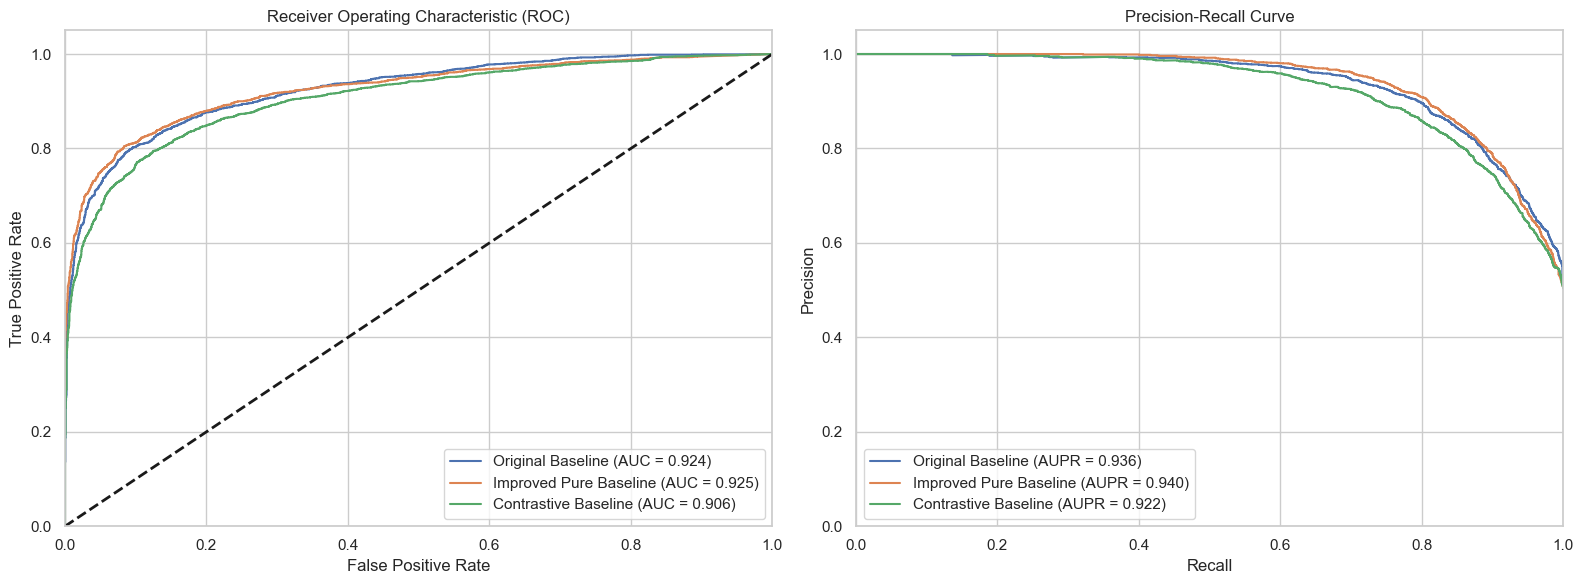

In [14]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(res["labels"], res["preds"])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(res["labels"], res["preds"])
    pr_auc = average_precision_score(res["labels"], res["preds"])
    ax2.plot(recall, precision, label=f'{name} (AUPR = {pr_auc:.3f})')

# ROC Settings
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# PR Settings
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()


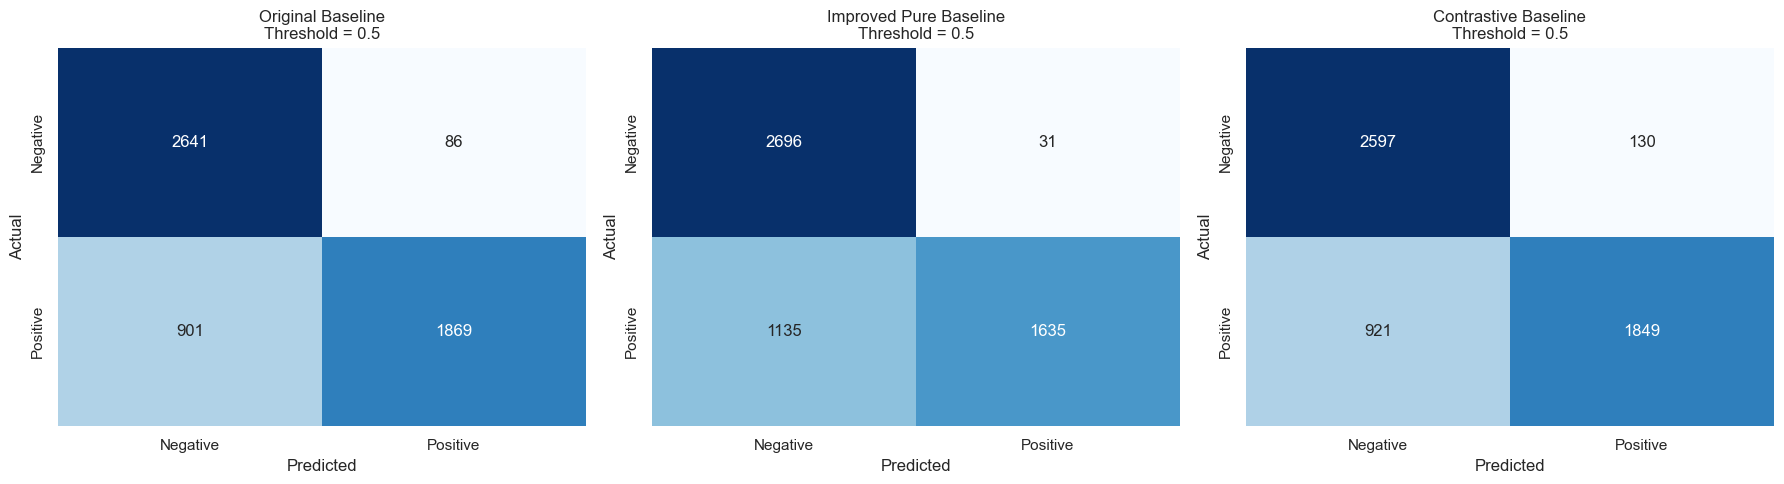

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, res) in enumerate(results.items()):
    # Binarize predictions
    binary_preds = (res["preds"] >= 0.5).astype(int)
    cm = confusion_matrix(res["labels"], binary_preds)
    
    # Normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}\nThreshold = 0.5')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Negative', 'Positive'])
    axes[i].set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()


Generating PCA for Improved Pure Baseline Drug Embeddings...


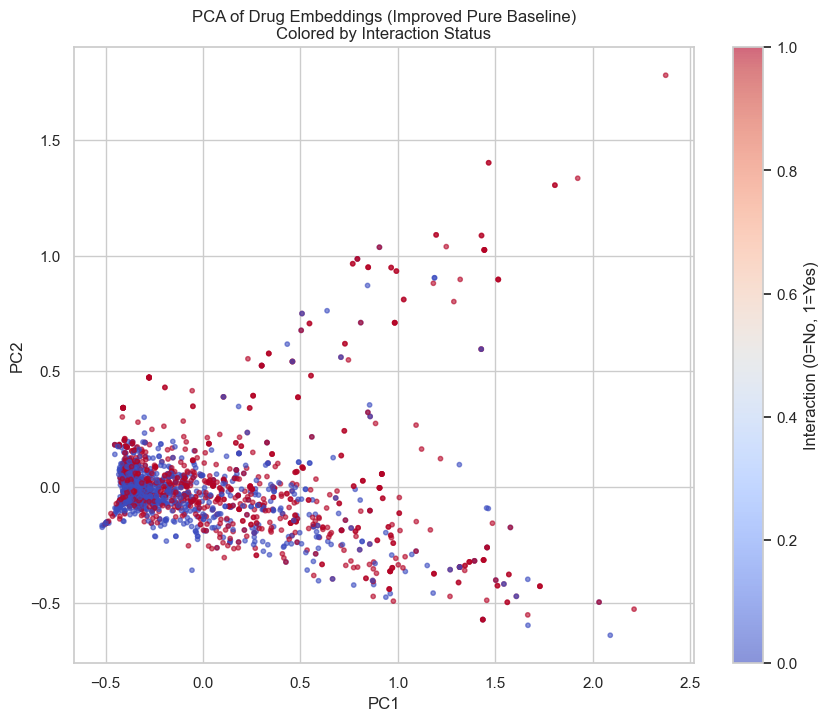

In [16]:

# Visualize Drug Embeddings for the Best Model (Improved Pure Baseline)
best_model_name = "Improved Pure Baseline"

if best_model_name in results:
    print(f"Generating PCA for {best_model_name} Drug Embeddings...")
    embs = results[best_model_name]["drug_embs"]
    labels = results[best_model_name]["labels"]
    
    # Subsample for speed/clarity if needed (e.g., first 2000 points)
    n_samples = 2000
    if len(embs) > n_samples:
        indices = np.random.choice(len(embs), n_samples, replace=False)
        embs_sub = embs[indices]
        labels_sub = labels[indices]
    else:
        embs_sub = embs
        labels_sub = labels
        
    pca = PCA(n_components=2)
    embs_pca = pca.fit_transform(embs_sub)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embs_pca[:, 0], embs_pca[:, 1], c=labels_sub, cmap='coolwarm', alpha=0.6, s=10)
    plt.colorbar(scatter, label='Interaction (0=No, 1=Yes)')
    plt.title(f'PCA of Drug Embeddings ({best_model_name})\nColored by Interaction Status')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()
else:
    print(f"Model {best_model_name} not found in results.")
